# РК-1. Задание 3. Вариант 19. Датасет 3
Группа: ИУ5-66Б  
Студент: Яншин Т.И.  
Дата: 03.05.2026  

Источник данных: https://www.kaggle.com/datasets/carlolepelaars/toy-dataset

## Цель работы
- Загрузить датасет с Kaggle и провести первичный анализ.
- Подготовить данные: проверить пропуски, при необходимости добавить и заполнить.
- Построить парные диаграммы для числовых признаков (требование для ИУ5-66Б).
- Выполнить масштабирование одного числового признака.
- Преобразовать один категориальный признак двумя способами: label encoding и one-hot encoding.
- Сформировать Word-отчет с иллюстрациями и ответами.

In [1]:
import importlib.util
import subprocess
import sys


def ensure_package(package, import_name=None):
    name = import_name or package
    if importlib.util.find_spec(name) is None:
        print(f"Устанавливаю пакет: {package}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])


for package, import_name in [
    ("pandas", "pandas"),
    ("numpy", "numpy"),
    ("matplotlib", "matplotlib"),
    ("seaborn", "seaborn"),
    ("scikit-learn", "sklearn"),
    ("kaggle", "kaggle"),
    ("python-docx", "docx"),
]:
    ensure_package(package, import_name)

import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
dataset_url = "https://www.kaggle.com/datasets/carlolepelaars/toy-dataset"
dataset_slug = "carlolepelaars/toy-dataset"

data_dir = Path("data/toy-dataset")
data_dir.mkdir(parents=True, exist_ok=True)

kaggle_config_dir = Path(os.environ.get("KAGGLE_CONFIG_DIR", Path.home() / ".kaggle"))
kaggle_json = kaggle_config_dir / "kaggle.json"
kaggle_token_file = kaggle_config_dir / "access_token"
kaggle_env_token = os.environ.get("KAGGLE_API_TOKEN")

if not kaggle_json.exists() and not kaggle_token_file.exists() and not kaggle_env_token:
    raise FileNotFoundError(
        "Файл kaggle.json или access_token не найден. "
        f"Поместите его в {kaggle_config_dir} и повторите запуск ячейки."
    )

from kaggle.api.kaggle_api_extended import KaggleApi

api = KaggleApi()
api.authenticate()
api.dataset_download_files(dataset_slug, path=data_dir, unzip=True)

csv_files = list(data_dir.rglob("*.csv"))
csv_files

Dataset URL: https://www.kaggle.com/datasets/carlolepelaars/toy-dataset


[WindowsPath('data/toy-dataset/toy_dataset.csv')]

In [5]:
if not csv_files:
    raise FileNotFoundError("CSV файл не найден в папке data/toy-dataset.")

csv_path = csv_files[0]
df = pd.read_csv(csv_path)
df.head()

,Number,City,Gender,Age,Income,Illness
0,1,Dallas,Male,41,40367.0,No
1,2,Dallas,Male,54,45084.0,No
2,3,Dallas,Male,42,52483.0,No
3,4,Dallas,Male,40,40941.0,No
4,5,Dallas,Male,46,50289.0,No


In [6]:
df.info()
df.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 6 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   Number   150000 non-null  int64  
 1   City     150000 non-null  object 
 2   Gender   150000 non-null  object 
 3   Age      150000 non-null  int64  
 4   Income   150000 non-null  float64
 5   Illness  150000 non-null  object 
dtypes: float64(1), int64(2), object(3)
memory usage: 6.9+ MB


,Number,City,Gender,Age,Income,Illness
count,150000.000000,150000,150000,150000.000000,150000.000000,150000
unique,NaN,8,2,NaN,NaN,2
top,NaN,New York City,Male,NaN,NaN,No
freq,NaN,50307,83800,NaN,NaN,137861
mean,75000.500000,NaN,NaN,44.950200,91252.798273,NaN
std,43301.414527,NaN,NaN,11.572486,24989.500948,NaN
min,1.000000,NaN,NaN,25.000000,-654.000000,NaN
25%,37500.750000,NaN,NaN,35.000000,80867.750000,NaN
50%,75000.500000,NaN,NaN,45.000000,93655.000000,NaN
75%,112500.250000,NaN,NaN,55.000000,104519.000000,NaN


In [7]:
missing = df.isna().sum()
missing

Number     0
City       0
Gender     0
Age        0
Income     0
Illness    0
dtype: int64

In [8]:
added_missing = False
if missing.sum() == 0:
    df = df.copy()
    num_cols = df.select_dtypes(include="number").columns.tolist()
    if num_cols:
        target_col = num_cols[0]
        rng = np.random.default_rng(42)
        mask = rng.random(len(df)) < 0.05
        df.loc[mask, target_col] = np.nan
        added_missing = True
        print(f"Искусственно добавлены пропуски в '{target_col}'.")
    else:
        print("Нет числовых колонок для внесения пропусков.")

df.isna().sum()

Искусственно добавлены пропуски в 'Number'.


Number     7490
City          0
Gender        0
Age           0
Income        0
Illness       0
dtype: int64

In [9]:
from sklearn.impute import SimpleImputer

df_filled = df.copy()
num_cols = df_filled.select_dtypes(include="number").columns.tolist()
cat_cols = df_filled.select_dtypes(exclude="number").columns.tolist()

if num_cols:
    num_imputer = SimpleImputer(strategy="median")
    df_filled[num_cols] = num_imputer.fit_transform(df_filled[num_cols])

if cat_cols:
    cat_imputer = SimpleImputer(strategy="most_frequent")
    df_filled[cat_cols] = cat_imputer.fit_transform(df_filled[cat_cols])

df_filled.isna().sum()

Number     0
City       0
Gender     0
Age        0
Income     0
Illness    0
dtype: int64

WindowsPath('reports/pairplot.png')

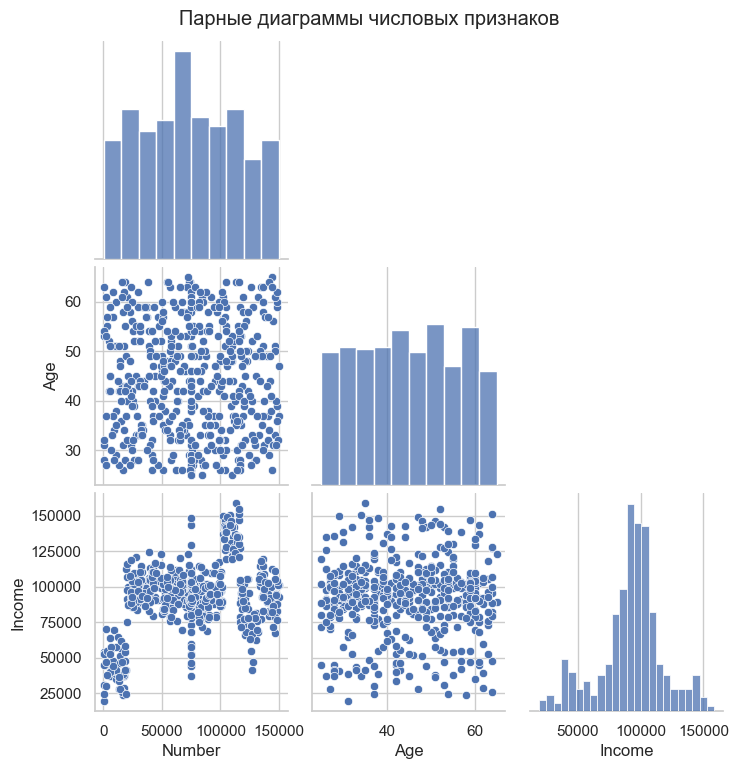

In [10]:
reports_dir = Path("reports")
reports_dir.mkdir(exist_ok=True)

numeric_cols = df_filled.select_dtypes(include="number").columns.tolist()
pairplot_df = df_filled[numeric_cols].copy()
if len(pairplot_df) > 500:
    pairplot_df = pairplot_df.sample(500, random_state=42)

sns.set_theme(style="whitegrid")
g = sns.pairplot(pairplot_df, corner=True, diag_kind="hist")
g.fig.suptitle("Парные диаграммы числовых признаков", y=1.02)

pairplot_path = reports_dir / "pairplot.png"
g.savefig(pairplot_path, dpi=200, bbox_inches="tight")
pairplot_path

In [11]:
from sklearn.preprocessing import MinMaxScaler

numeric_cols = df_filled.select_dtypes(include="number").columns.tolist()
if not numeric_cols:
    raise ValueError("В наборе данных нет числовых признаков для масштабирования.")

scale_col = "Income" if "Income" in numeric_cols else numeric_cols[0]

scaler = MinMaxScaler()
df_scaled = df_filled.copy()
df_scaled[f"{scale_col}_minmax"] = scaler.fit_transform(df_scaled[[scale_col]])

df_scaled[[scale_col, f"{scale_col}_minmax"]].head()

,Income,Income_minmax
0,40367.0,0.230700
1,45084.0,0.257228
2,52483.0,0.298840
3,40941.0,0.233928
4,50289.0,0.286501


WindowsPath('reports/scaling.png')

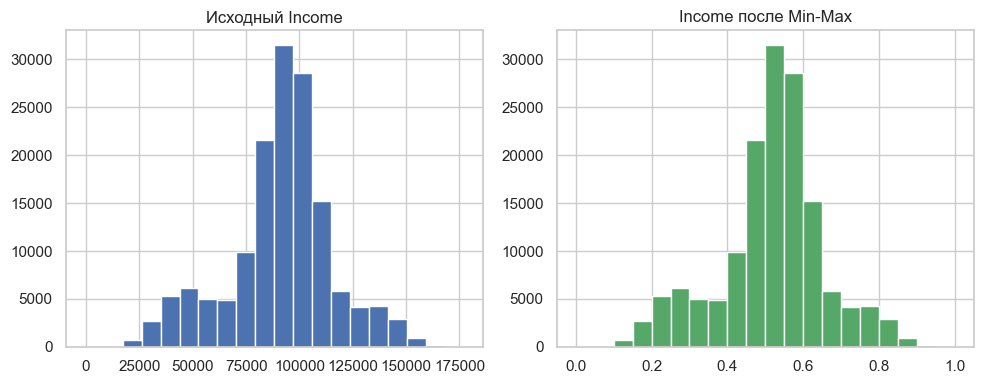

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].hist(df_scaled[scale_col], bins=20, color="#4C72B0")
ax[0].set_title(f"Исходный {scale_col}")
ax[1].hist(df_scaled[f"{scale_col}_minmax"], bins=20, color="#55A868")
ax[1].set_title(f"{scale_col} после Min-Max")

scale_plot_path = reports_dir / "scaling.png"
fig.tight_layout()
fig.savefig(scale_plot_path, dpi=200, bbox_inches="tight")
scale_plot_path

In [13]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

cat_cols = df_filled.select_dtypes(exclude="number").columns.tolist()
if not cat_cols:
    raise ValueError("В наборе данных нет категориальных признаков для кодирования.")

encode_col = "Gender" if "Gender" in cat_cols else cat_cols[0]

le = LabelEncoder()
df_encoded = df_filled.copy()
df_encoded[f"{encode_col}_label"] = le.fit_transform(df_encoded[encode_col])

try:
    ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
except TypeError:
    ohe = OneHotEncoder(sparse=False, handle_unknown="ignore")

ohe_matrix = ohe.fit_transform(df_encoded[[encode_col]])
ohe_cols = [f"{encode_col}_oh_{c}" for c in ohe.categories_[0]]

df_ohe = pd.concat(
    [
        df_encoded.drop(columns=[encode_col]),
        pd.DataFrame(ohe_matrix, columns=ohe_cols, index=df_encoded.index),
    ],
    axis=1,
)

df_encoded[[encode_col, f"{encode_col}_label"]].head()

,Gender,Gender_label
0,Male,1
1,Male,1
2,Male,1
3,Male,1
4,Male,1


In [14]:
df_ohe.head()

,Number,City,Age,Income,Illness,Gender_label,Gender_oh_Female,Gender_oh_Male
0,1.0,Dallas,41.0,40367.0,No,1,0.0,1.0
1,2.0,Dallas,54.0,45084.0,No,1,0.0,1.0
2,3.0,Dallas,42.0,52483.0,No,1,0.0,1.0
3,4.0,Dallas,40.0,40941.0,No,1,0.0,1.0
4,5.0,Dallas,46.0,50289.0,No,1,0.0,1.0


In [16]:
label_plot_path = reports_dir / "label_encoding.png"
ohe_plot_path = reports_dir / "one_hot_encoding.png"

label_counts = df_encoded[encode_col].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(label_counts.index.astype(str), label_counts.values, color="#4C72B0")
ax.set_title(f"Label encoding для {encode_col}")
ax.set_xlabel(encode_col)
ax.set_ylabel("Количество")
fig.tight_layout()
fig.savefig(label_plot_path, dpi=200, bbox_inches="tight")
plt.close(fig)

ohe_only_cols = [col for col in df_ohe.columns if col.startswith(f"{encode_col}_oh_")]
ohe_counts = df_ohe[ohe_only_cols].sum().sort_index()
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar([c.replace(f"{encode_col}_oh_", "") for c in ohe_counts.index], ohe_counts.values, color="#55A868")
ax.set_title(f"One-hot encoding для {encode_col}")
ax.set_xlabel(encode_col)
ax.set_ylabel("Количество")
fig.tight_layout()
fig.savefig(ohe_plot_path, dpi=200, bbox_inches="tight")
plt.close(fig)

label_plot_path, ohe_plot_path

(WindowsPath('reports/label_encoding.png'),
 WindowsPath('reports/one_hot_encoding.png'))

## Картинки кодирования

**Label encoding:**

![Label encoding](reports/label_encoding.png)

**One-hot encoding:**

![One-hot encoding](reports/one_hot_encoding.png)

## Ответы на вопросы
- Масштабирование выполнено с помощью Min-Max scaler для признака `scale_col`. Этот метод приводит значения к диапазону [0, 1], сохраняет форму распределения и удобен для алгоритмов, чувствительных к масштабу.
- Для категориального признака `encode_col` применены два подхода:
  - Label encoding дает компактное числовое представление и подходит для моделей, которые не интерпретируют числовой порядок как расстояние (например, деревья решений).
  - One-hot encoding не вводит искусственный порядок между категориями и предпочтителен для линейных моделей и большинства статистических алгоритмов.